# Retail Demand Forecasting
This project focuses on forecasting daily retail demand across multiple stores and product categories using gradient boosting algorithms. Accurate demand forecasting enables better inventory planning, stock optimization, and supply chain decision-making.

**Prediction Target**
- Daily product demand

**Models Used**
- LightGBM
- XGBoost

**Key Techniques**
- Time-series feature engineering
- Lag and rolling window features
- Categorical encoding
- Model comparison and evaluation



<a id='1'></a>
## 1. Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        12,
})

SEED = 42
print('Libraries loaded')

Libraries loaded


In [4]:
# Loading the dataset

df = pd.read_csv("demand_forecasting.csv", parse_dates=['Date'])

print(f'Shape      : {df.shape}')
print(f'Date range : {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Stores     : {df["Store ID"].nunique()}   |   Products: {df["Product ID"].nunique()}')
print(f'Categories : {df["Category"].unique().tolist()}')
print(f'Regions    : {df["Region"].unique().tolist()}')
df.head()

Shape      : (76000, 16)
Date range : 2022-01-01  →  2024-01-30
Stores     : 5   |   Products: 20
Categories : ['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture']
Regions    : ['North', 'South', 'East', 'West']


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [5]:
# Data types & missing values
info = pd.DataFrame({
    'dtype':     df.dtypes,
    'nulls':     df.isnull().sum(),
    'null_%':    (df.isnull().mean() * 100).round(2),
    'nunique':   df.nunique(),
}).sort_values('null_%', ascending=False)

print(info.to_string())

                             dtype  nulls  null_%  nunique
Date                datetime64[ns]      0     0.0      760
Store ID                    object      0     0.0        5
Product ID                  object      0     0.0       20
Category                    object      0     0.0        5
Region                      object      0     0.0        4
Inventory Level              int64      0     0.0     1426
Units Sold                   int64      0     0.0      330
Units Ordered                int64      0     0.0      996
Price                      float64      0     0.0    15396
Discount                     int64      0     0.0        6
Weather Condition           object      0     0.0        4
Promotion                    int64      0     0.0        2
Competitor Pricing         float64      0     0.0    15963
Seasonality                 object      0     0.0        4
Epidemic                     int64      0     0.0        2
Demand                       int64      0     0.0      3

In [6]:
# Target distribution
print('Demand statistics:')
print(df['Demand'].describe().round(2))

Demand statistics:
count    76000.00
mean       104.32
std         46.96
min          4.00
25%         71.00
50%        100.00
75%        133.00
max        430.00
Name: Demand, dtype: float64


### 2.1 Data Leakage Assessment

Before training the forecasting models, it is important to verify whether any features unintentionally reveal future information.

During correlation analysis, **Units Sold** showed a very strong relationship with the target variable. However, this value would not be available when making future demand predictions, making it a source of data leakage.

Similarly, **Units Ordered** represents information generated after demand is realized and therefore cannot be considered a valid predictor.

To ensure the model reflects a real-world forecasting scenario, both features are excluded from the training dataset.

In [7]:
# Leakage check
print('Correlation with Demand:')
for col in ['Units Sold', 'Units Ordered', 'Inventory Level']:
    print(f'  {col:>20s} : {df[col].corr(df["Demand"]):.4f}')

# Flag leakage columns — we will exclude them in feature engineering
LEAKAGE_COLS = ['Units Sold', 'Units Ordered']
print(f'\nColumns to drop from features: {LEAKAGE_COLS}')

Correlation with Demand:
            Units Sold : 0.8334
         Units Ordered : 0.5120
       Inventory Level : 0.1266

Columns to drop from features: ['Units Sold', 'Units Ordered']


<a id='3'></a>
## 3. Exploratory Data Analysis (EDA)

The objective of this analysis is to understand demand behavior, identify seasonal patterns, examine relationships between variables, and detect potential issues before feature engineering and model development.

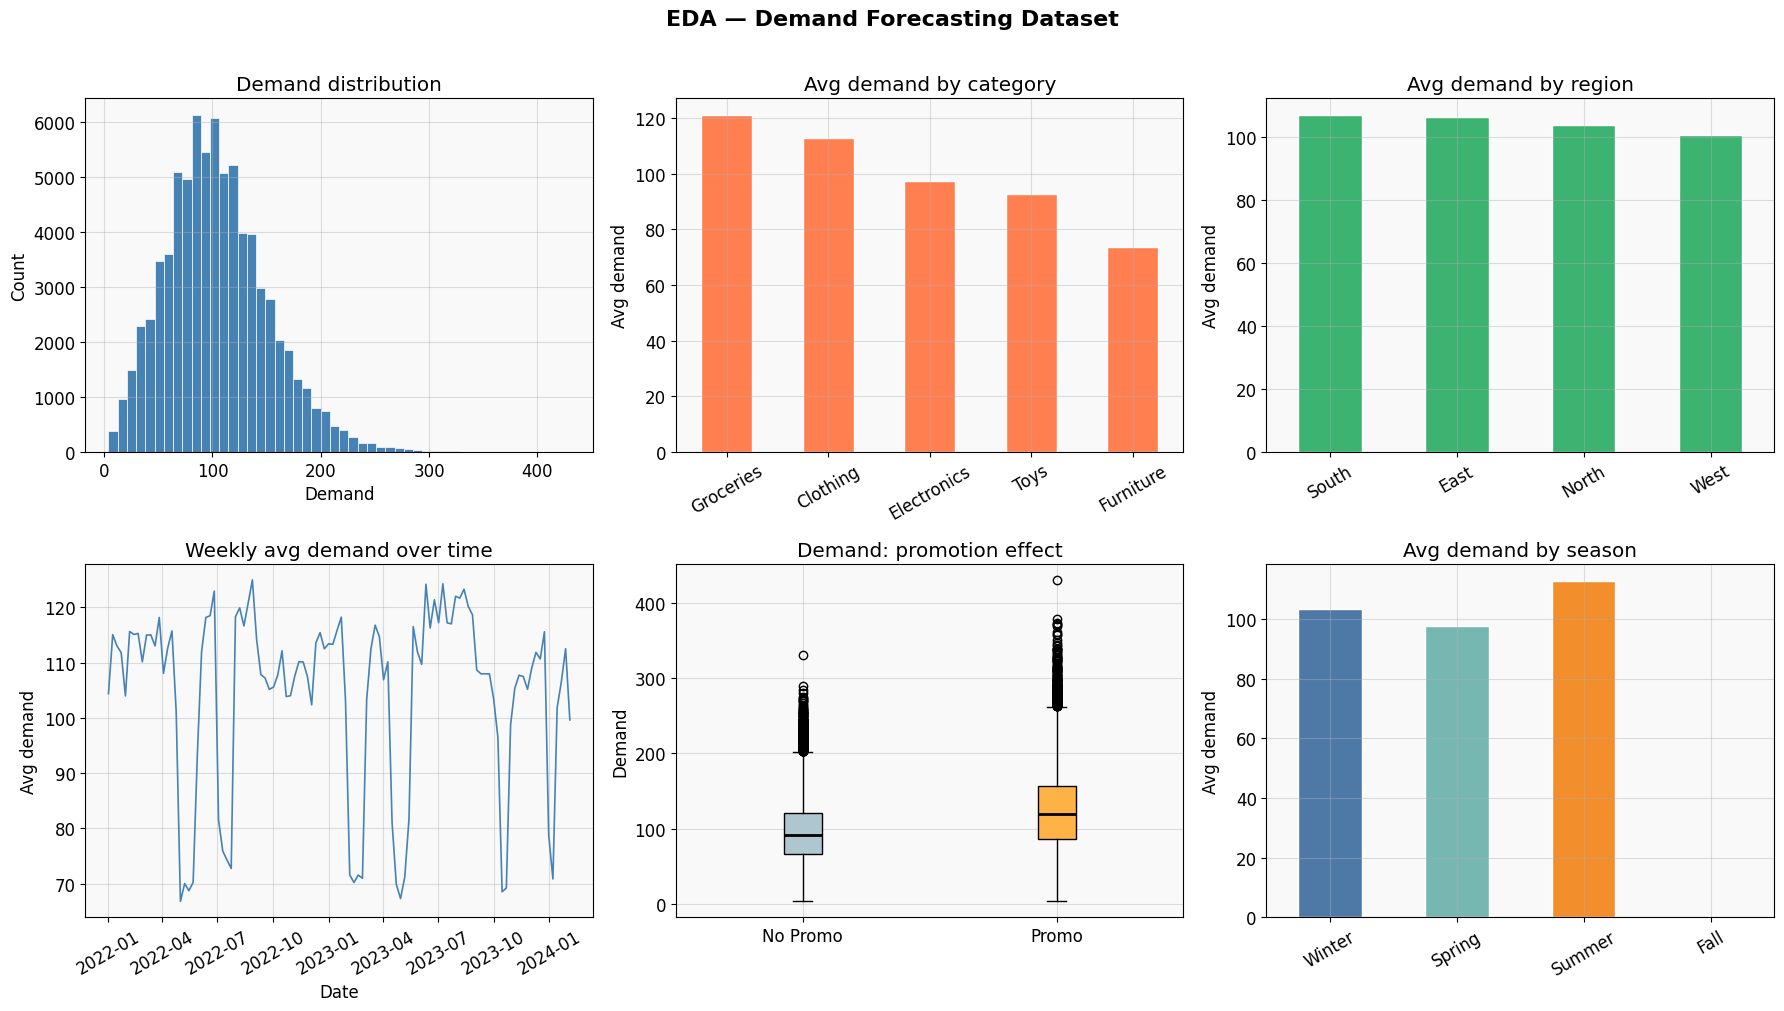

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Demand Forecasting Dataset', fontsize=16, fontweight='bold', y=1.01)

# 1. Target distribution
ax = axes[0, 0]
ax.hist(df['Demand'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Demand distribution')
ax.set_xlabel('Demand'); ax.set_ylabel('Count')

# 2. Demand by category
ax = axes[0, 1]
cat_means = df.groupby('Category')['Demand'].mean().sort_values(ascending=False)
cat_means.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Avg demand by category')
ax.set_xlabel(''); ax.set_ylabel('Avg demand')
ax.tick_params(axis='x', rotation=30)

# 3. Demand by region
ax = axes[0, 2]
reg_means = df.groupby('Region')['Demand'].mean().sort_values(ascending=False)
reg_means.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Avg demand by region')
ax.set_xlabel(''); ax.set_ylabel('Avg demand')
ax.tick_params(axis='x', rotation=30)

# 4. Demand over time (weekly avg)
ax = axes[1, 0]
weekly = df.groupby('Date')['Demand'].mean().resample('W').mean()
ax.plot(weekly.index, weekly.values, color='steelblue', linewidth=1.2)
ax.set_title('Weekly avg demand over time')
ax.set_xlabel('Date'); ax.set_ylabel('Avg demand')
ax.tick_params(axis='x', rotation=30)

# 5. Demand: promotion vs no promotion
ax = axes[1, 1]
promo_data = [df[df['Promotion'] == 0]['Demand'].values,
              df[df['Promotion'] == 1]['Demand'].values]
bp = ax.boxplot(promo_data, labels=['No Promo', 'Promo'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#aec6cf')
bp['boxes'][1].set_facecolor('#ffb347')
ax.set_title('Demand: promotion effect')
ax.set_ylabel('Demand')

# 6. Demand by season
ax = axes[1, 2]
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_means = df.groupby('Seasonality')['Demand'].mean().reindex(season_order)
season_means.plot(kind='bar', ax=ax,
                  color=['#4e79a7', '#76b7b2', '#f28e2b', '#e15759'],
                  edgecolor='white')
ax.set_title('Avg demand by season')
ax.set_xlabel(''); ax.set_ylabel('Avg demand')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

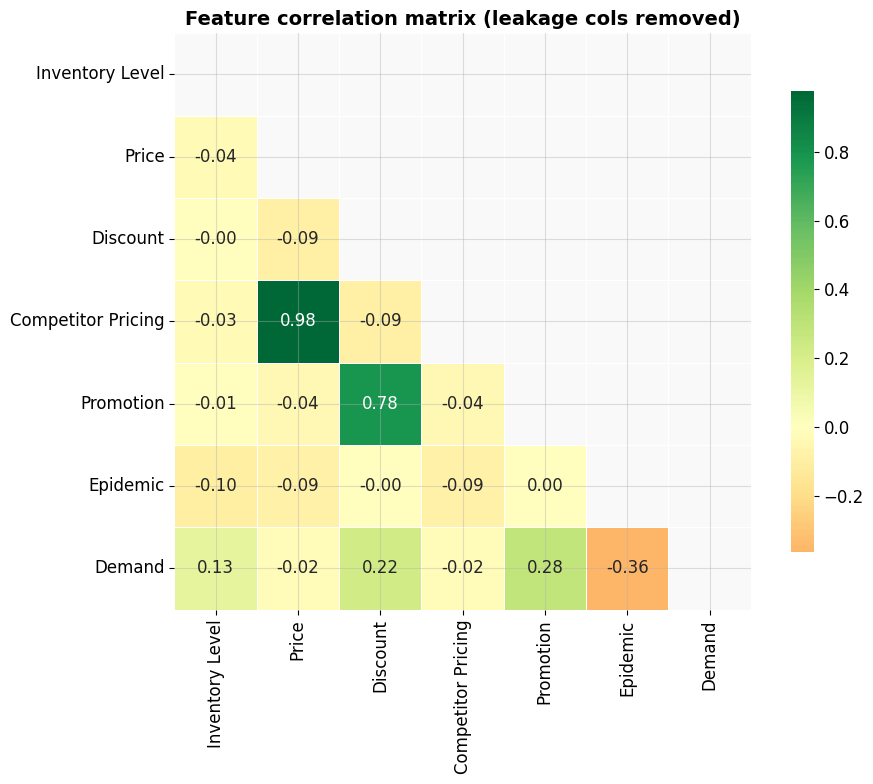

In [9]:
# Correlation heatmap (numeric features only — excluding leakage cols)
num_cols = ['Inventory Level', 'Price', 'Discount',
            'Competitor Pricing', 'Promotion', 'Epidemic', 'Demand']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix (leakage cols removed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Feature engineering plays a critical role in retail demand forecasting because purchasing behavior is influenced by historical demand, seasonality, pricing, and promotions.

To capture these patterns, several groups of predictive features were created.

### Temporal Features
- Day of week
- Month
- Week of year
- Quarter
- Weekend indicator

These features help the model learn weekly and seasonal purchasing trends.

---

### Historical Demand Features

Lag variables were created to provide the model with previous demand information.

- Lag 1
- Lag 7
- Lag 14
- Lag 28

These features capture short-term and medium-term purchasing behavior.

---

### Rolling Statistics

Rolling averages and rolling standard deviations over 7-day and 30-day windows were calculated to represent recent demand trends and demand variability.

---

### Pricing Features

Additional pricing features were generated, including competitor price differences and effective discount rates, to capture price sensitivity.

---

### Categorical Features

Categorical variables such as Store, Product, Category, Region, Weather, and Seasonality were encoded for use in gradient boosting models.

> Note: Potential leakage variables (Units Sold and Units Ordered) were removed before feature generation to ensure a realistic forecasting pipeline.

In [10]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create time-series and derived features. Does NOT encode categoricals
    (that is done after the train/val split to avoid leakage)."""
    df = df.copy().sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)
    grp = df.groupby(['Store ID', 'Product ID'])['Demand']

    # ── Date features ──
    df['day_of_week']  = df['Date'].dt.dayofweek
    df['day_of_month'] = df['Date'].dt.day
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month']        = df['Date'].dt.month
    df['quarter']      = df['Date'].dt.quarter
    df['year']         = df['Date'].dt.year
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

    # ── Lag features (shift prevents leakage) ──
    for lag in [1, 7, 14, 28]:
        df[f'demand_lag_{lag}'] = grp.shift(lag)

    # ── Rolling features (shift(1) so current row is excluded) ──
    for window in [7, 30]:
        df[f'demand_roll_mean_{window}'] = grp.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        df[f'demand_roll_std_{window}'] = grp.transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).std()
        )

    # ── Price-derived ──
    df['price_vs_competitor'] = df['Price'] - df['Competitor Pricing']
    df['discount_pct']        = df['Discount'] / (df['Price'] + 1e-6)

    return df


In [11]:
# Create feature table
df_feat = create_features(df)
print(f'Features created. Shape: {df_feat.shape}')
df_feat[['Date', 'Store ID', 'Product ID', 'Demand',
         'demand_lag_1', 'demand_lag_7',
         'demand_roll_mean_7', 'demand_roll_std_7']].head(10)

Features created. Shape: (76000, 33)


,Date,Store ID,Product ID,Demand,demand_lag_1,demand_lag_7,demand_roll_mean_7,demand_roll_std_7
0,2022-01-01,S001,P0001,115,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,84,115.0,NaN,115.000000,NaN
2,2022-01-03,S001,P0001,132,84.0,NaN,99.500000,21.920310
3,2022-01-04,S001,P0001,67,132.0,NaN,110.333333,24.337899
4,2022-01-05,S001,P0001,110,67.0,NaN,99.500000,29.399546
5,2022-01-06,S001,P0001,146,110.0,NaN,101.600000,25.890153
6,2022-01-07,S001,P0001,87,146.0,NaN,109.000000,29.407482
7,2022-01-08,S001,P0001,113,87.0,115.0,105.857143,28.103550
8,2022-01-09,S001,P0001,87,113.0,84.0,105.571429,28.005102
9,2022-01-10,S001,P0001,99,87.0,132.0,106.000000,27.640550


In [12]:
# Inspect lag/rolling output
print(df_feat[['Demand', 'demand_lag_1', 'demand_lag_7',
               'demand_roll_mean_7', 'demand_roll_std_7']].head(10))

   Demand  demand_lag_1  demand_lag_7  demand_roll_mean_7  demand_roll_std_7
0     115           NaN           NaN                 NaN                NaN
1      84         115.0           NaN          115.000000                NaN
2     132          84.0           NaN           99.500000          21.920310
3      67         132.0           NaN          110.333333          24.337899
4     110          67.0           NaN           99.500000          29.399546
5     146         110.0           NaN          101.600000          25.890153
6      87         146.0           NaN          109.000000          29.407482
7     113          87.0         115.0          105.857143          28.103550
8      87         113.0          84.0          105.571429          28.005102
9      99          87.0         132.0          106.000000          27.640550


In [13]:
# Categorical columns to encode (done after split)
CAT_COLS = ['Store ID', 'Product ID', 'Category', 'Region',
            'Weather Condition', 'Seasonality']

# Numeric feature columns (NO Units Sold / Units Ordered)
NUMERIC_COLS = [
    'Inventory Level', 'Price', 'Discount', 'Competitor Pricing',
    'Promotion', 'Epidemic',
    'price_vs_competitor', 'discount_pct',
    'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter', 'year', 'is_weekend',
    'demand_lag_1', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28',
    'demand_roll_mean_7', 'demand_roll_std_7',
    'demand_roll_mean_30', 'demand_roll_std_30',
]

TARGET = 'Demand'
print(f'Categorical columns : {len(CAT_COLS)}')
print(f'Numeric columns     : {len(NUMERIC_COLS)}')

Categorical columns : 6
Numeric columns     : 23


<a id='5'></a>
## 5. Train / Validation Split

To evaluate the forecasting models realistically, the dataset was divided chronologically instead of using a random split.

A random split would allow future observations to appear in the training data, leading to data leakage and overly optimistic performance estimates.

Using a time-based split ensures that the model is trained only on historical information and evaluated on future demand, closely matching real-world deployment scenarios.

In [14]:
# Dropping rows with NaN in lag/rolling columns (first ~28 days per group)
feature_cols_pre_enc = NUMERIC_COLS  # we'll add encoded cols after
df_model = df_feat.dropna(subset=NUMERIC_COLS + [TARGET]).reset_index(drop=True)
print(f'Before dropping NaNs: {df_feat.shape}')
print(f'After dropping NaNs : {df_model.shape}')

# Time-based split
SPLIT_DATE = pd.to_datetime('2024-01-01')
train_df = df_model[df_model['Date'] <  SPLIT_DATE].sort_values('Date').reset_index(drop=True)
val_df   = df_model[df_model['Date'] >= SPLIT_DATE].sort_values('Date').reset_index(drop=True)

print(f'\nTrain : {len(train_df):>7,} rows  ({train_df["Date"].min().date()} to {train_df["Date"].max().date()})')
print(f'Val   : {len(val_df):>7,} rows  ({val_df["Date"].min().date()} to {val_df["Date"].max().date()})')

Before dropping NaNs: (76000, 33)
After dropping NaNs : (73200, 33)

Train :  70,200 rows  (2022-01-29 to 2023-12-31)
Val   :   3,000 rows  (2024-01-01 to 2024-01-30)


In [15]:
# Label encode: fit on train, transform both
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(train_df[col].astype(str))
    train_df[f'{col}_enc'] = le.transform(train_df[col].astype(str))

    # Handle unseen categories in validation
    val_series = val_df[col].astype(str)
    val_mapped = val_series.map(lambda x: x if x in le.classes_ else le.classes_[0])
    val_df[f'{col}_enc'] = le.transform(val_mapped)

    label_encoders[col] = le

ENC_COLS = [f'{c}_enc' for c in CAT_COLS]
FEATURE_COLS = NUMERIC_COLS + ENC_COLS

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]

print(f'Feature count : {len(FEATURE_COLS)}')
print(f'NaN check     : train={X_train.isnull().sum().sum()}, val={X_val.isnull().sum().sum()}')

Feature count : 29
NaN check     : train=0, val=0


In [16]:
def evaluate(y_true, y_pred, model_name='Model'):
    """Compute and print regression metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f'{"─" * 40}')
    print(f'  {model_name}')
    print(f'  MAE  : {mae:.3f}')
    print(f'  RMSE : {rmse:.3f}')
    print(f'  MAPE : {mape:.2f}%')
    print(f'  R2   : {r2:.4f}')
    print(f'{"─" * 40}')

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

<a id='6'></a>
## 6. LightGBM Model

In [17]:
lgb_params = {
    'objective':         'regression',
    'metric':            'rmse',
    'learning_rate':     0.05,
    'num_leaves':        127,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':           -1,
    'seed':              SEED,
}

lgb_train_ds = lgb.Dataset(X_train, label=y_train)
lgb_val_ds   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train_ds)

evals_result_lgb = {}

lgb_model = lgb.train(
    lgb_params,
    lgb_train_ds,
    num_boost_round=2000,
    valid_sets=[lgb_train_ds, lgb_val_ds],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=200),
        lgb.record_evaluation(evals_result_lgb),
    ],
)

print(f'\nBest iteration: {lgb_model.best_iteration}')

[200]	train's rmse: 15.5571	val's rmse: 17.4058
[400]	train's rmse: 10.1858	val's rmse: 13.6337
[600]	train's rmse: 7.14353	val's rmse: 11.6481
[800]	train's rmse: 5.48314	val's rmse: 10.6748
[1000]	train's rmse: 4.37235	val's rmse: 10.0288
[1200]	train's rmse: 3.66851	val's rmse: 9.68041
[1400]	train's rmse: 3.15251	val's rmse: 9.46332
[1600]	train's rmse: 2.76012	val's rmse: 9.34957
[1800]	train's rmse: 2.43346	val's rmse: 9.25067
[2000]	train's rmse: 2.16335	val's rmse: 9.18871

Best iteration: 2000


In [18]:
# LightGBM predictions & metrics
lgb_pred = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
lgb_pred = np.clip(lgb_pred, 0, None)

lgb_metrics = evaluate(y_val, lgb_pred, 'LightGBM')

────────────────────────────────────────
  LightGBM
  MAE  : 5.861
  RMSE : 9.189
  MAPE : 10.43%
  R2   : 0.9589
────────────────────────────────────────


<a id='7'></a>
## 7. XGBoost Model

In [19]:
xgb_params = {
    'objective':        'reg:squarederror',
    'eval_metric':      'rmse',
    'learning_rate':    0.05,
    'max_depth':        7,
    'min_child_weight': 5,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'seed':             SEED,
    'tree_method':      'hist',
    'verbosity':        0,
}

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_COLS)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURE_COLS)

evals_result_xgb = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=3000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    evals_result=evals_result_xgb,
    verbose_eval=False,
    callbacks=[
        xgb.callback.EarlyStopping(rounds=50, metric_name='rmse',
                                   data_name='val', save_best=True),
        xgb.callback.EvaluationMonitor(period=200),
    ],
)

print(f'\nBest iteration: {xgb_model.best_iteration}')

[0]	train-rmse:46.08357	val-rmse:44.67926
[200]	train-rmse:22.23914	val-rmse:23.17774
[400]	train-rmse:16.68994	val-rmse:19.10898
[600]	train-rmse:12.59736	val-rmse:16.12068
[800]	train-rmse:9.72393	val-rmse:14.03402
[1000]	train-rmse:7.71831	val-rmse:12.58766
[1200]	train-rmse:6.21902	val-rmse:11.54901
[1400]	train-rmse:5.15153	val-rmse:10.79018
[1600]	train-rmse:4.38591	val-rmse:10.26934
[1800]	train-rmse:3.84732	val-rmse:9.93422
[2000]	train-rmse:3.40462	val-rmse:9.69355
[2200]	train-rmse:3.06265	val-rmse:9.49913
[2400]	train-rmse:2.78190	val-rmse:9.36898
[2600]	train-rmse:2.53955	val-rmse:9.27621
[2800]	train-rmse:2.32786	val-rmse:9.20315
[2999]	train-rmse:2.14883	val-rmse:9.14707

Best iteration: 2997


In [20]:
# XGBoost predictions & metrics
xgb_pred = xgb_model.predict(dval, iteration_range=(0, xgb_model.best_iteration))
xgb_pred = np.clip(xgb_pred, 0, None)

xgb_metrics = evaluate(y_val, xgb_pred, 'XGBoost')

────────────────────────────────────────
  XGBoost
  MAE  : 6.039
  RMSE : 9.147
  MAPE : 10.28%
  R2   : 0.9593
────────────────────────────────────────


<a id='8'></a>
## 8. Model Comparison & Evaluation

In [21]:
# Create val_plot AFTER both models have produced predictions
val_plot = val_df.copy()
val_plot['lgb_pred'] = lgb_pred
val_plot['xgb_pred'] = xgb_pred
print(f'val_plot ready: {val_plot.shape}')

val_plot ready: (3000, 41)


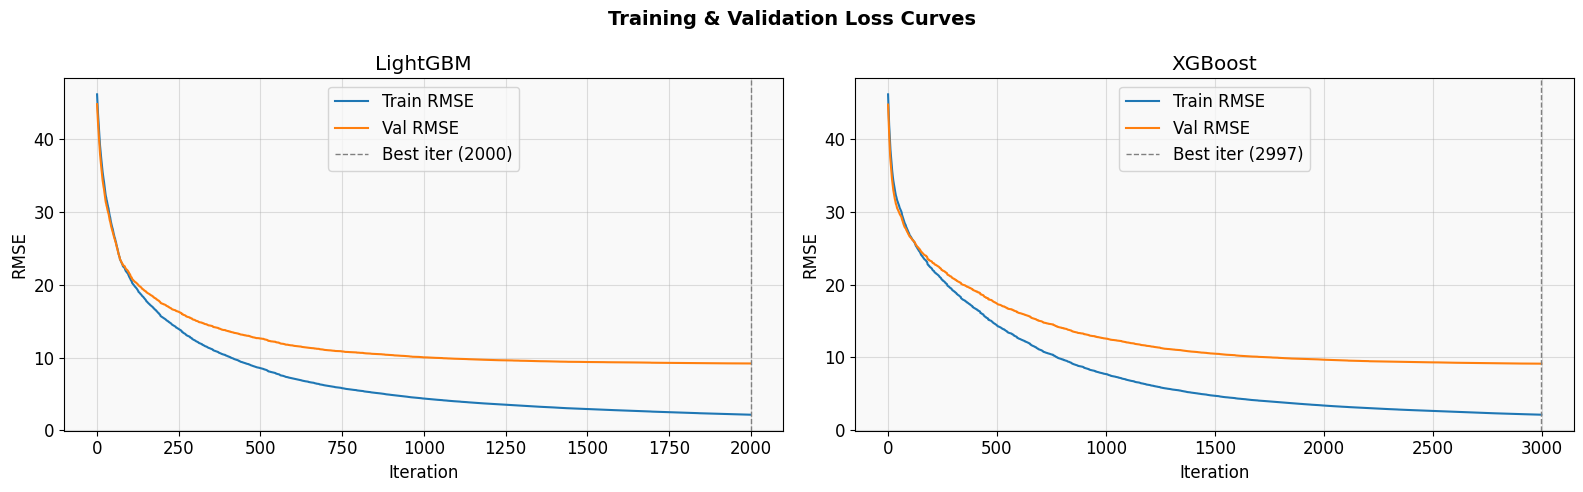

In [22]:
# Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training & Validation Loss Curves', fontsize=14, fontweight='bold')

# LightGBM
train_losses_lgb = evals_result_lgb['train']['rmse']
val_losses_lgb   = evals_result_lgb['val']['rmse']
axes[0].plot(train_losses_lgb, label='Train RMSE', linewidth=1.5)
axes[0].plot(val_losses_lgb,   label='Val RMSE',   linewidth=1.5)
best_lgb = lgb_model.best_iteration
if best_lgb and best_lgb > 0:
    axes[0].axvline(best_lgb, color='gray', ls='--', label=f'Best iter ({best_lgb})', lw=1)
axes[0].set_title('LightGBM'); axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('RMSE')
axes[0].legend()

# XGBoost
train_losses_xgb = evals_result_xgb['train']['rmse']
val_losses_xgb   = evals_result_xgb['val']['rmse']
axes[1].plot(train_losses_xgb, label='Train RMSE', linewidth=1.5)
axes[1].plot(val_losses_xgb,   label='Val RMSE',   linewidth=1.5)
best_xgb = xgb_model.best_iteration
if best_xgb and best_xgb > 0:
    axes[1].axvline(best_xgb, color='gray', ls='--', label=f'Best iter ({best_xgb})', lw=1)
axes[1].set_title('XGBoost'); axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

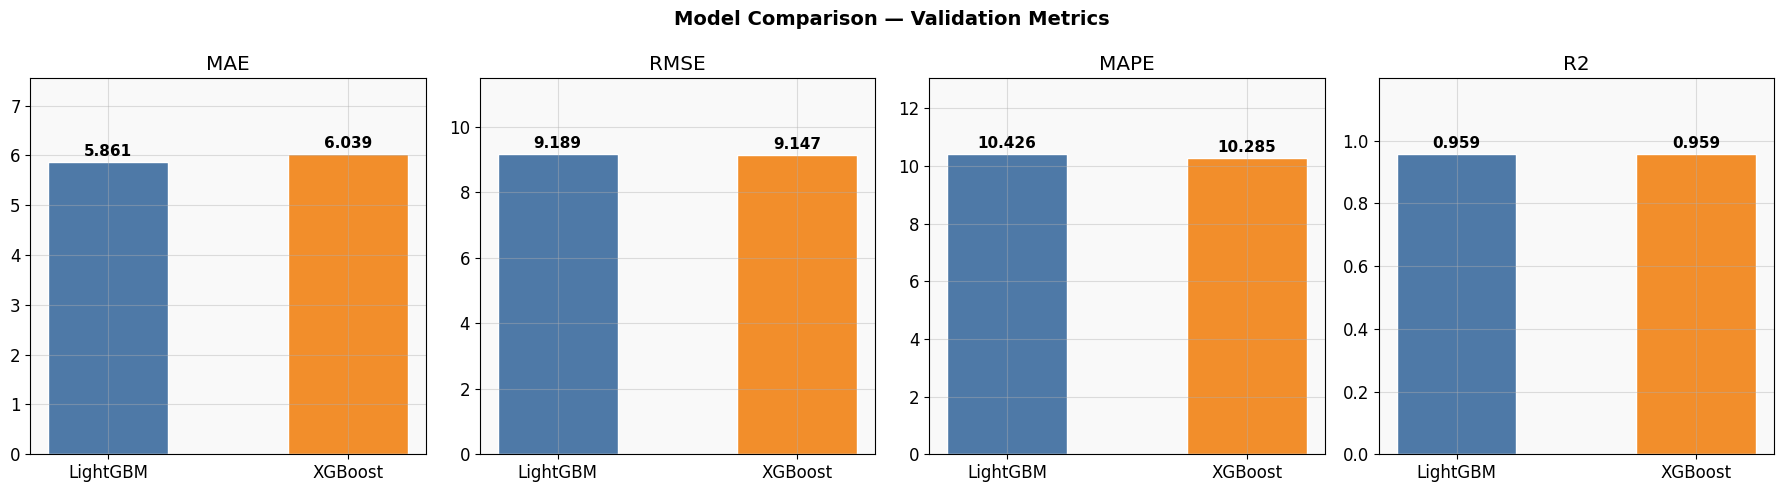


Metrics summary:
             MAE    RMSE     MAPE      R2
LightGBM  5.8611  9.1887  10.4262  0.9589
XGBoost   6.0385  9.1472  10.2849  0.9593


In [23]:
# Side-by-side metrics comparison
metrics_df = pd.DataFrame([lgb_metrics, xgb_metrics], index=['LightGBM', 'XGBoost'])

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison — Validation Metrics', fontsize=14, fontweight='bold')

colors = ['#4e79a7', '#f28e2b']
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE', 'R2']):
    ax = axes[i]
    vals = metrics_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(metric)
    ax.set_ylim(0, vals.max() * 1.25)

plt.tight_layout()
plt.show()

print('\nMetrics summary:')
print(metrics_df.round(4).to_string())

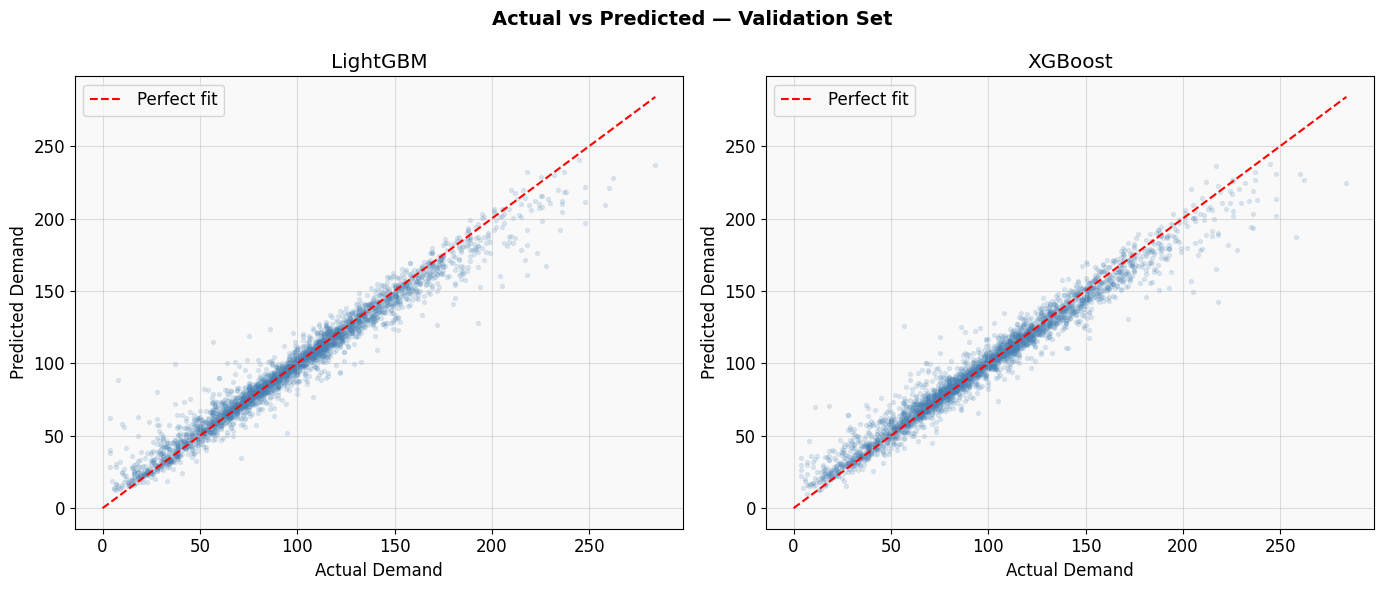

In [24]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted — Validation Set', fontsize=14, fontweight='bold')

for ax, preds, title in zip(axes, [lgb_pred, xgb_pred], ['LightGBM', 'XGBoost']):
    ax.scatter(y_val, preds, alpha=0.15, s=8, color='steelblue')
    max_val = max(y_val.max(), preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Demand'); ax.set_ylabel('Predicted Demand')
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Feature Importance

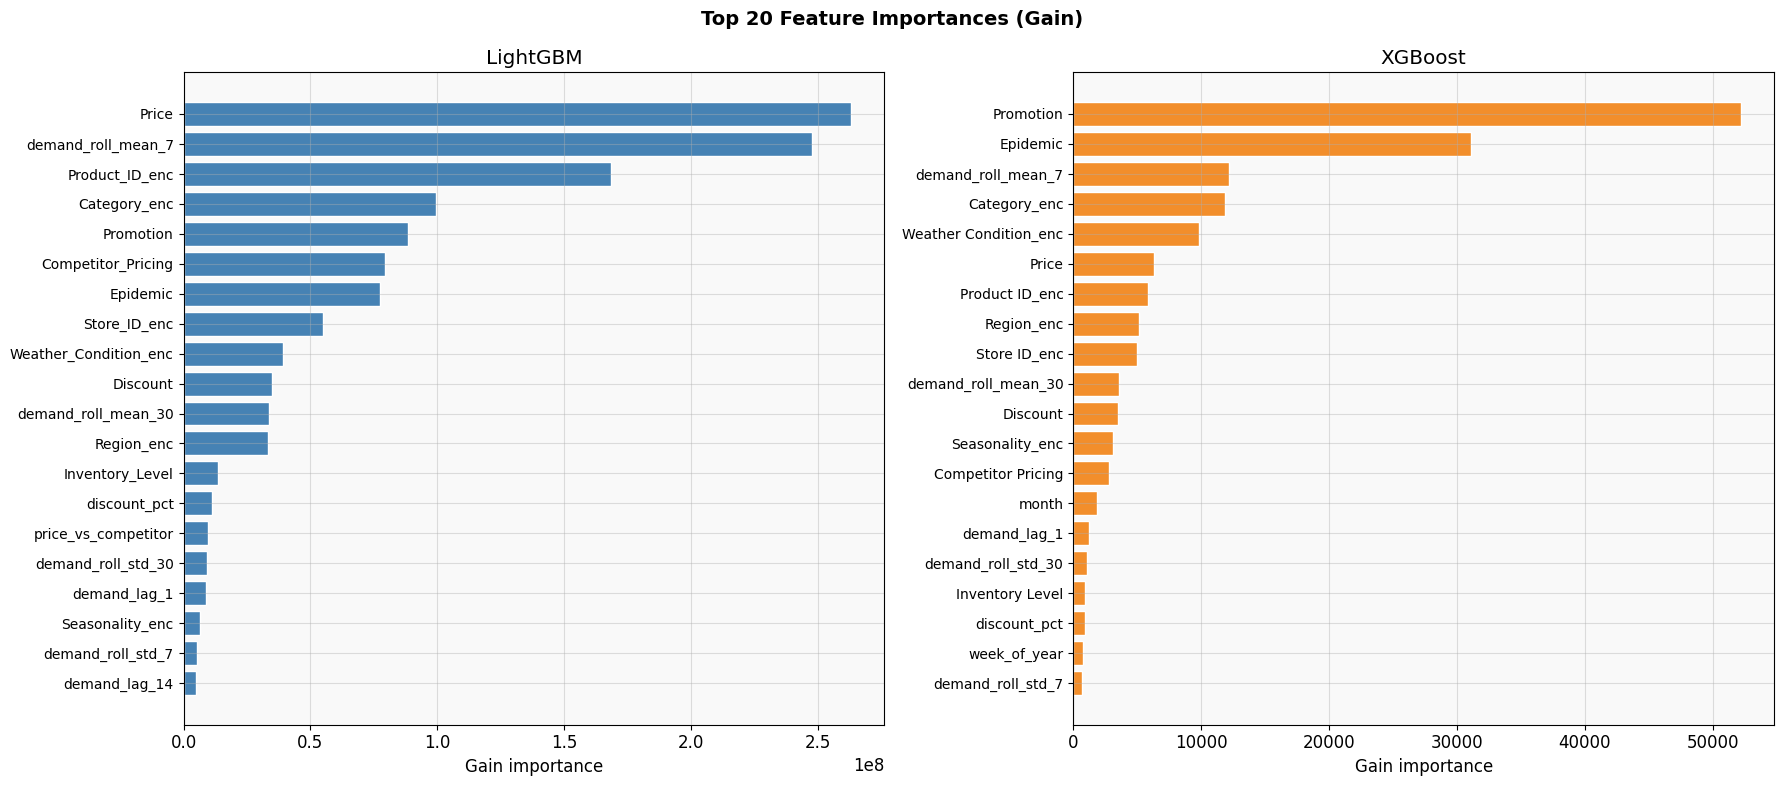

In [25]:
# Feature importance (gain)
lgb_imp = pd.DataFrame({
    'Feature':    lgb_model.feature_name(),
    'Importance': lgb_model.feature_importance(importance_type='gain'),
}).sort_values('Importance', ascending=False).head(20)

xgb_imp_raw = xgb_model.get_score(importance_type='gain')
xgb_imp = pd.DataFrame(list(xgb_imp_raw.items()),
                        columns=['Feature', 'Importance']) \
            .sort_values('Importance', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 20 Feature Importances (Gain)', fontsize=14, fontweight='bold')

for ax, imp_df, title, color in zip(
        axes, [lgb_imp, xgb_imp], ['LightGBM', 'XGBoost'],
        ['steelblue', '#f28e2b']):
    ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
            color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel('Gain importance')
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

## 10. Forecast Visualisation

Plot actual vs predicted demand for a sample store-product pair, plus
residual analysis and per-category error breakdown.

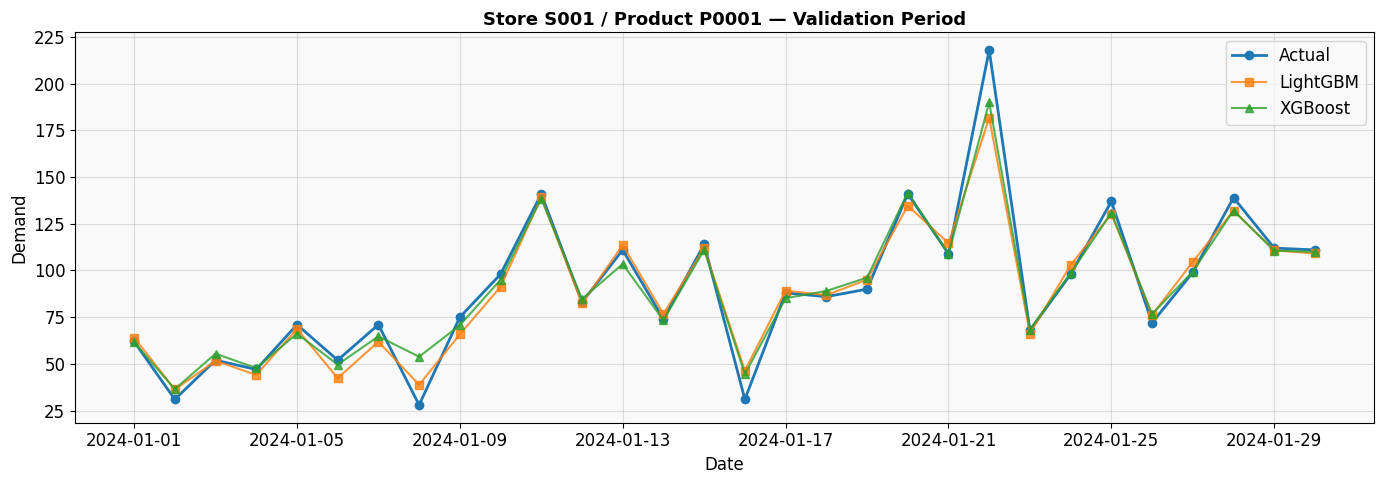

In [26]:
# Time-series plot for one store-product pair
sample = val_plot[(val_plot['Store ID'] == 'S001') & (val_plot['Product ID'] == 'P0001')]
sample = sample.sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['Date'], sample['Demand'],   label='Actual',   marker='o', linewidth=2)
ax.plot(sample['Date'], sample['lgb_pred'], label='LightGBM', marker='s', linewidth=1.5, alpha=0.8)
ax.plot(sample['Date'], sample['xgb_pred'], label='XGBoost',  marker='^', linewidth=1.5, alpha=0.8)
ax.set_title('Store S001 / Product P0001 — Validation Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Demand'); ax.legend()
plt.tight_layout()
plt.show()

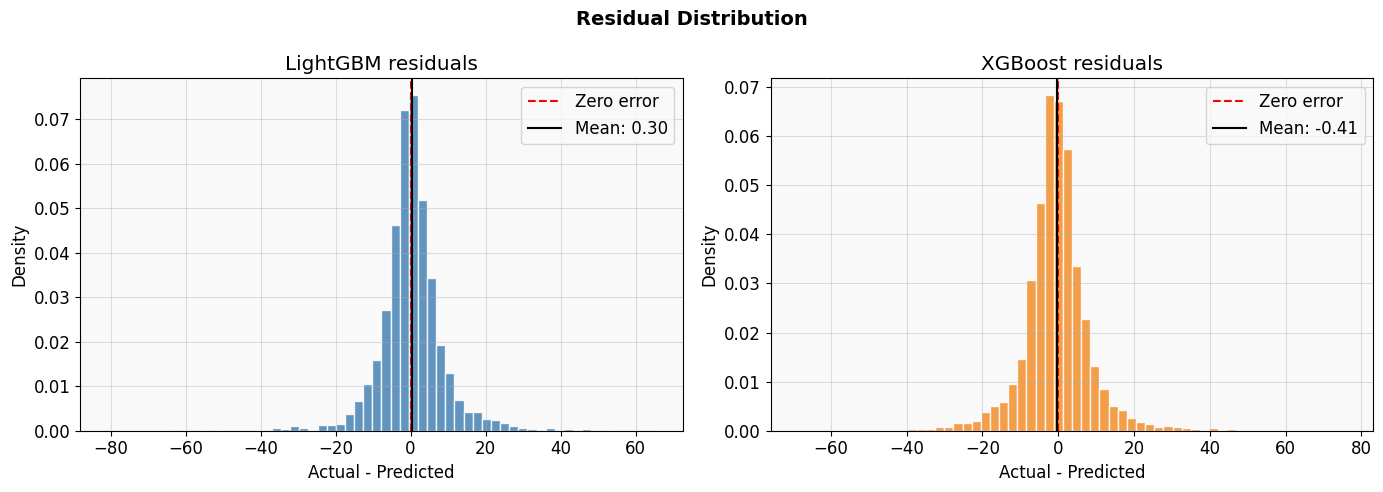

In [27]:
# Residual distributions
lgb_errors = y_val.values - lgb_pred
xgb_errors = y_val.values - xgb_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Distribution', fontsize=14, fontweight='bold')

for ax, errors, title, color in zip(
    axes, [lgb_errors, xgb_errors],
    ['LightGBM residuals', 'XGBoost residuals'],
    ['steelblue', '#f28e2b']
):
    ax.hist(errors, bins=60, density=True, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', ls='--', lw=1.5, label='Zero error')
    ax.axvline(errors.mean(), color='black', ls='-', lw=1.5,
               label=f'Mean: {errors.mean():.2f}')
    ax.set_title(title); ax.set_xlabel('Actual - Predicted'); ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

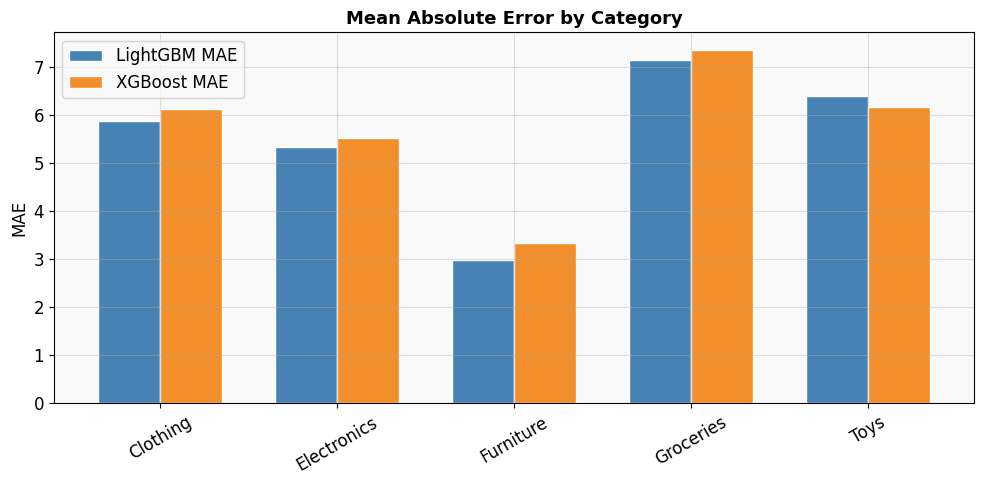

             LightGBM MAE  XGBoost MAE
Category                              
Clothing            5.866        6.110
Electronics         5.324        5.508
Furniture           2.988        3.339
Groceries           7.127        7.345
Toys                6.392        6.150


In [28]:
# Per-category error breakdown
val_plot['lgb_abs_err'] = np.abs(y_val.values - lgb_pred)
val_plot['xgb_abs_err'] = np.abs(y_val.values - xgb_pred)

cat_err = val_plot.groupby('Category')[['lgb_abs_err', 'xgb_abs_err']].mean()
cat_err.columns = ['LightGBM MAE', 'XGBoost MAE']

ax = cat_err.plot(kind='bar', figsize=(10, 5), color=['steelblue', '#f28e2b'],
                  edgecolor='white', width=0.7)
ax.set_title('Mean Absolute Error by Category', fontsize=13, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=30); ax.legend()
plt.tight_layout()
plt.show()

print(cat_err.round(3).to_string())

In [29]:
# Final summary
print('=' * 50)
print('  FINAL MODEL SUMMARY')
print('=' * 50)
for name, m in [('LightGBM', lgb_metrics), ('XGBoost', xgb_metrics)]:
    print(f'  {name:<12}  MAE={m["MAE"]:.2f}  RMSE={m["RMSE"]:.2f}  '
          f'MAPE={m["MAPE"]:.1f}%  R2={m["R2"]:.4f}')
print('=' * 50)
winner = 'LightGBM' if lgb_metrics['RMSE'] <= xgb_metrics['RMSE'] else 'XGBoost'
print(f'  Lower RMSE: {winner}')
print('=' * 50)

  FINAL MODEL SUMMARY
  LightGBM      MAE=5.86  RMSE=9.19  MAPE=10.4%  R2=0.9589
  XGBoost       MAE=6.04  RMSE=9.15  MAPE=10.3%  R2=0.9593
  Lower RMSE: XGBoost


# Conclusion

This project developed an end-to-end retail demand forecasting pipeline using LightGBM and XGBoost.

The workflow included exploratory data analysis, leakage detection, feature engineering, chronological validation, model training, performance evaluation, and business interpretation.

Key findings from this project include:

- Historical demand features significantly improved forecasting accuracy.
- Time-based feature engineering effectively captured seasonal purchasing behaviour.
- Both LightGBM and XGBoost produced strong predictive performance on unseen data.
- Feature importance analysis confirmed that recent demand history is the strongest predictor of future demand.

Future improvements could include incorporating external variables such as holidays, weather forecasts, marketing campaigns, and deep learning approaches like Temporal Fusion Transformers or LSTMs for long-horizon forecasting.

# Business Impact

Accurate demand forecasting enables retailers to:

- Reduce stock shortages and excess inventory
- Improve replenishment planning
- Optimize warehouse operations
- Lower inventory holding costs
- Increase customer satisfaction through better product availability

Although this project is developed on a public retail dataset, the same forecasting pipeline can be adapted for inventory management, supply chain planning, and demand optimization in real-world retail environments.